In [ ]:
import gc
import itertools
import math
import os
import random
import sys
from collections import Counter, defaultdict
from copy import deepcopy
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Any, Callable, Literal, TypeAlias

import einops
import numpy as np
import pandas as pd
import torch as t
from datasets import load_dataset
from IPython.display import clear_output, display
from jaxtyping import Float, Int
from rich import print as rprint
from rich.table import Table

from transformer_lens import HookedTransformer, HookedTransformerConfig
from tabulate import tabulate
from torch import Tensor, nn
from torch.nn import functional as F
from tqdm.auto import tqdm
from transformer_lens import ActivationCache, loading_from_pretrained
from transformer_lens.hook_points import HookPoint
from transformer_lens.utils import get_act_name, to_numpy
from transformer_lens import utils

import matplotlib.pyplot as plt
import seaborn as sns
import torch

from scipy.sparse import csr_array
from scipy.sparse.csgraph import maximum_bipartite_matching, min_weight_full_bipartite_matching

device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")


## Model & State_dict Loading 

In [16]:
import importlib

arch = "l8_h8_attn_wd"

# ------------------- Load Model Config -------------------

def load_named_config(module_name: str, config_name: str) -> dict:
    """
    Import a module that defines CONFIGS: Dict[str, Dict[str, Any]]
    and return CONFIGS[config_name].
    """
    try:
        mod = importlib.import_module(module_name)
    except Exception as e:
        raise ImportError(f"Could not import config module '{module_name}': {e}") from e

    if not hasattr(mod, "CONFIGS"):
        raise AttributeError(f"Module '{module_name}' does not define CONFIGS.")

    CONFIGS = getattr(mod, "CONFIGS")
    if config_name not in CONFIGS:
        available = ", ".join(sorted(CONFIGS.keys()))
        raise KeyError(f"Config '{config_name}' not found in {module_name}. Available: {available}")

    return dict(CONFIGS[config_name])  # copy so we can tweak

cfg_dict = load_named_config("model_configs", arch)


# ------------------- Model Configuration -------------------

# Build HookedTransformerConfig using the loaded config
cfg = HookedTransformerConfig(
    n_layers=cfg_dict["n_layers"],
    d_model=cfg_dict["d_model"],
    n_heads=cfg_dict["n_heads"],
    d_head=cfg_dict["d_head"],
    d_mlp=cfg_dict.get("d_mlp", None),
    n_ctx=cfg_dict["n_ctx"],
    act_fn=cfg_dict.get("act_fn", "gelu"),
    d_vocab=cfg_dict["d_vocab"],
    init_weights=True,
    tokenizer_name=cfg_dict["tokenizer_name"],
    model_name=cfg_dict.get("model_name", arch),
    attn_only=cfg_dict.get("attn_only", False),
)

In [ ]:
# Constants
SCRATCH = "Path to root directory"
NUM_LAYERS = cfg.n_layers
NUM_HEADS = cfg.n_heads
ATTN_ONLY = cfg.attn_only

#SEEDS = [2,3,1,4,5]
chkpt_dir = SCRATCH + "chkpts/" + arch
SEEDS = [i for i in range(1, 51)]
if "gpt2" in arch:
    SEEDS = [i for i in range(1, 6)]
chkpt_file = "final.pt"
shard = 9
epoch = 1

# Load models
models = []
for SEED in SEEDS:
    cfg.seed = SEED
    cfg.init_weights = True
    model = HookedTransformer(cfg)
    models.append(model)

for ind, SEED in enumerate(SEEDS):
    if (arch == "gpt2") or (arch == "gpt2_wd"):
        model_state_dict = t.load(chkpt_dir + f"/gpt2_seed{SEED}_shard{shard}_epoch{epoch}_owt/{chkpt_file}")
        models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)
    else:
        if ATTN_ONLY:
            model_state_dict = t.load(
                chkpt_dir + f"/causal_attn_only_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
            )
            models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

        else:
            model_state_dict = t.load(
                chkpt_dir + f"/causal_attn_l{NUM_LAYERS}_h{NUM_HEADS}_seed{SEED}_epoch{epoch}_c4_gelu/{chkpt_file}"
            )
            models[ind].load_and_process_state_dict(model_state_dict, fold_ln=False)

## Prompt Sentences Data

In [4]:
import pickle

prompts_file = "100_prompts"

with open(f"./{prompts_file}.pkl", "rb") as f:
    prompts = pickle.load(f)

print(f"Loaded {len(prompts)} prompts from ./{prompts_file}.pkl")

Loaded 100 prompts from ./100_prompts.pkl


## Caching Model Activations & Attention Scores

In [5]:
# Setting device to CPU as GPU memory is insufficient for this computation, but for smaller number of prompts/models it can be set to GPU
device = 'cpu'

# run prompts to collect caches (using CPU to avoid CUDA OOM)
prompts_cache = []
for prompt in prompts:
    cache_for_prompt = []
    for ind in range(len(SEEDS)):
        _, cache_i = models[ind].run_with_cache(prompt, remove_batch_dim=True)
        # Keep cache on CPU
        cache_i = cache_i.to('cpu')
        cache_for_prompt.append(cache_i)
    prompts_cache.append(cache_for_prompt)

## Attention-Head Stability
#### Creates a prompts_cs_matrix to hold head-to-head comparisons using cosine similarity

In [6]:
# Define function to extract lower triangular part of attention matrix
def lower_triang(mat):
    
    lower_triangular_mat = torch.tril(mat)
    mask = torch.tril(torch.ones_like(mat, device=device)).bool()
    lower_triangular_vec = lower_triangular_mat[mask]
    return lower_triangular_vec

# Initialize cosine similarity module
cos = t.nn.CosineSimilarity(dim=1, eps=1e-08)

# Constants
NUM_MODELS = len(models)
NUM_HEADS = models[0].cfg.n_heads
NUM_LAYERS = models[0].cfg.n_layers
NUM_PROMPTS = len(prompts_cache)

# tickmarks for plotting
ticklabel_layers = [i for i in range(1,NUM_LAYERS+1)]
ticklabel_heads = [i for i in range(1,NUM_HEADS+1)]
ticklabel_models = [i for i in range(1,NUM_MODELS+1)]

# Free memory held by models
#del models
#del model_state_dict
torch.cuda.empty_cache()


print("Computing cosine similarity matrix...")
prompts_cs_matrix = t.empty(( NUM_LAYERS, NUM_HEADS, NUM_MODELS, NUM_HEADS, NUM_PROMPTS), device=device)

# Setting Anchor seed/refit
anchor = 0

# Compute cosine-similarity matrix across layers/heads/models per prompt
for ind_prompt in range(NUM_PROMPTS):
    cache = prompts_cache[ind_prompt]
    cache_anchor = cache[anchor].to(device)
    
    for layer in range(NUM_LAYERS):
        for head_anchor in range(NUM_HEADS):
                
                head_anchor_attn = cache_anchor[utils.get_act_name('pattern',layer,'a')][head_anchor]
                head_anchor_attn = lower_triang(head_anchor_attn.to(device))
                head_anchor_attn = t.unsqueeze(head_anchor_attn, 0)

                for model_i in range(NUM_MODELS):
                    cache_model_i = cache[model_i].to(device)
                    for head_pair in range(NUM_HEADS):
                        head_i_attn = cache_model_i[utils.get_act_name('pattern',layer,'a')][head_pair]
                        head_i_attn = lower_triang(head_i_attn.to(device))
                        head_i_attn = t.unsqueeze(head_i_attn, 0)
                        cos_score_i = cos(head_anchor_attn, head_i_attn)
                        prompts_cs_matrix[layer, head_anchor, model_i, head_pair, ind_prompt] = cos_score_i
                        del head_i_attn, cos_score_i

                    del cache_model_i

                del head_anchor_attn

    del cache_anchor
    torch.cuda.empty_cache()


Computing cosine similarity matrix...


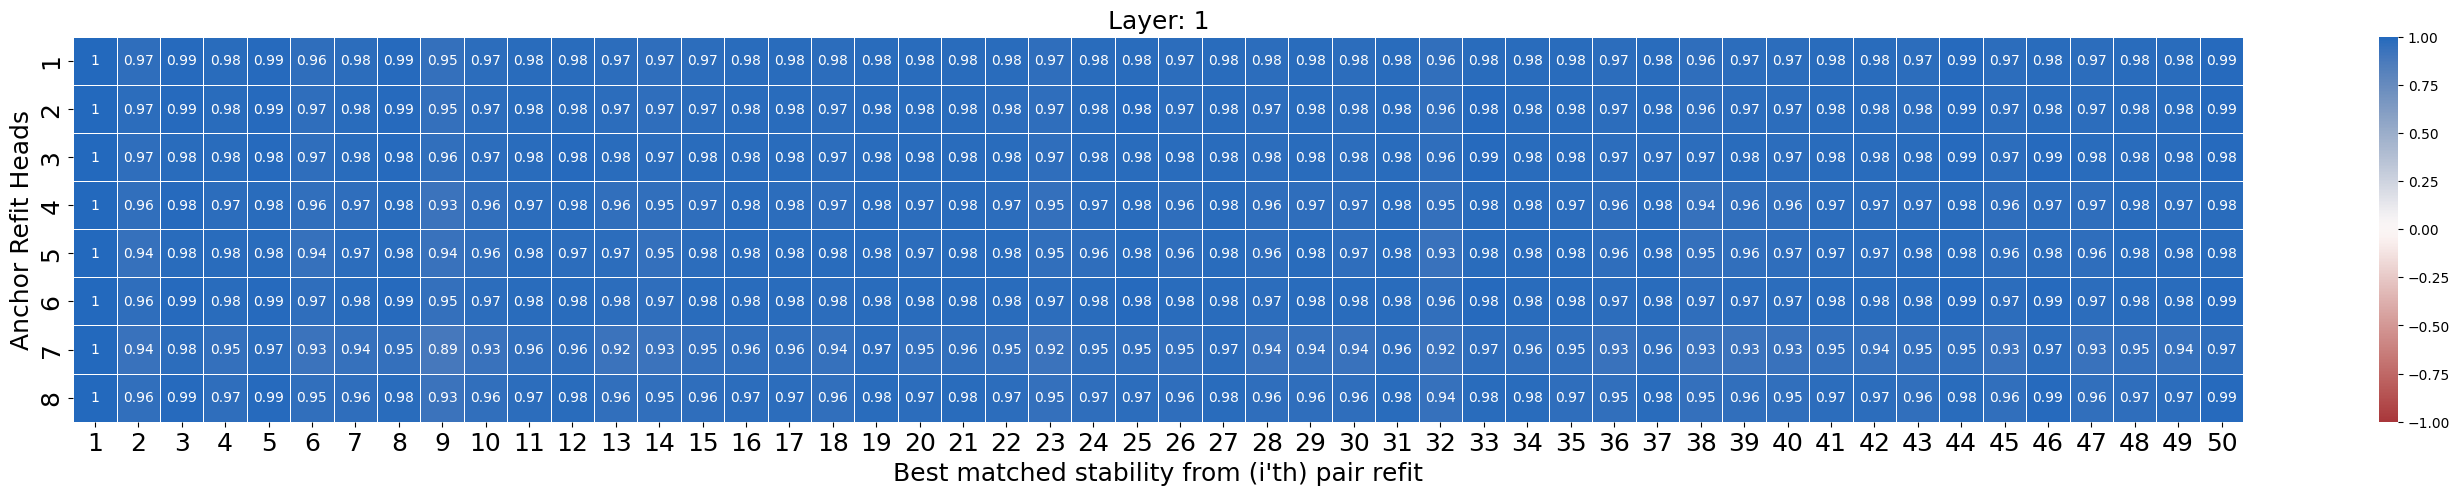

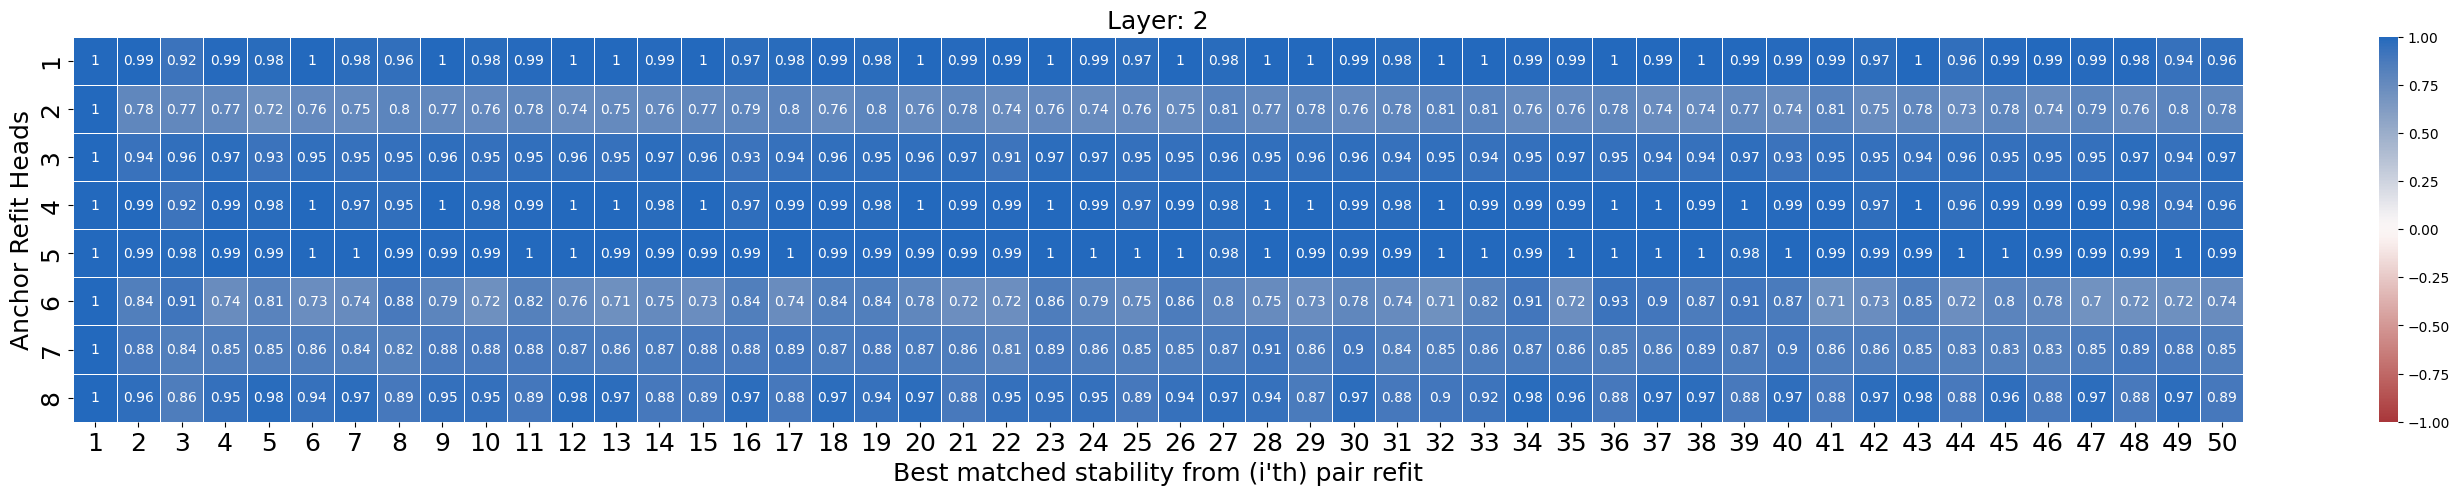

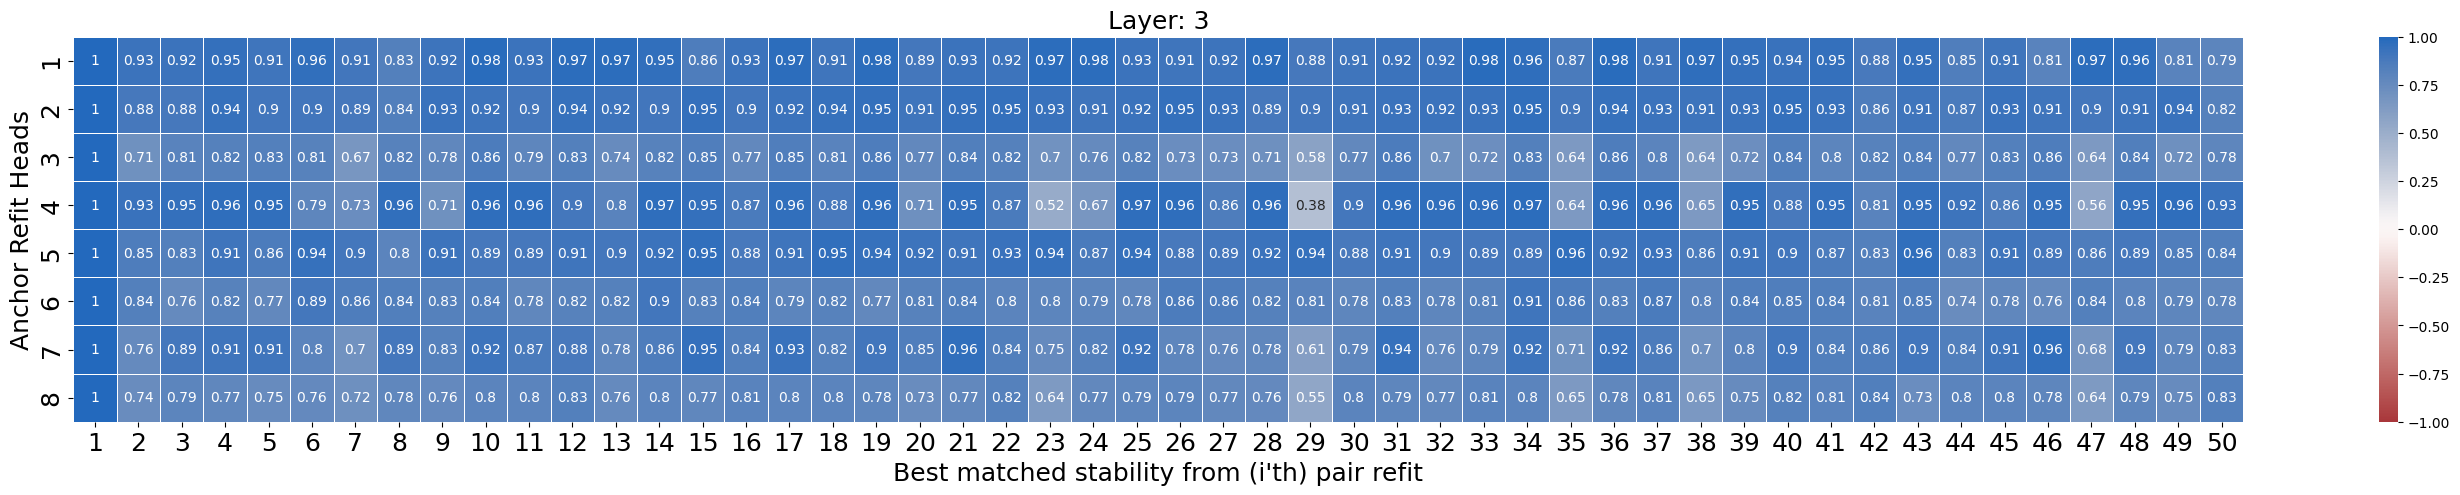

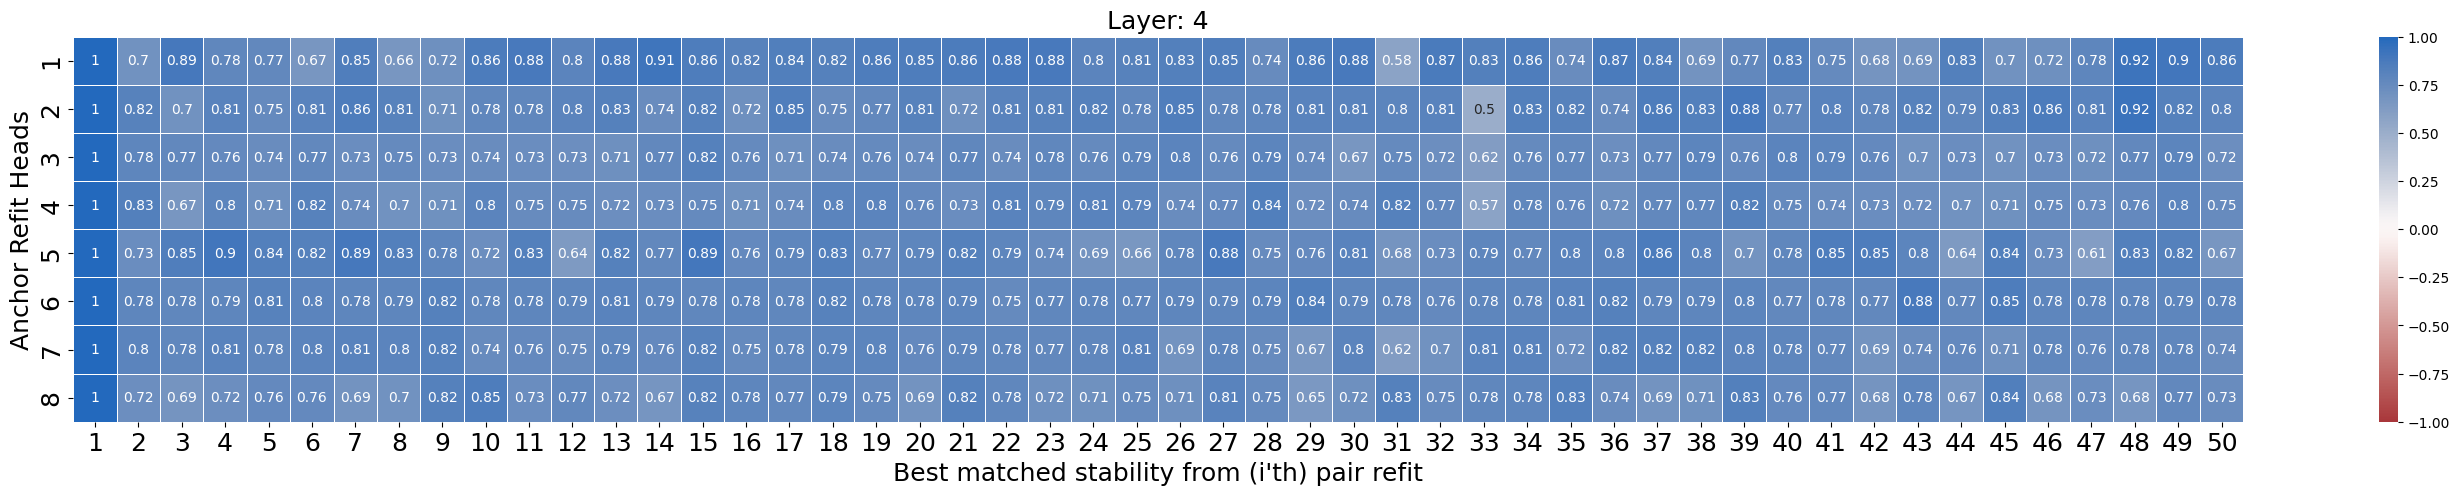

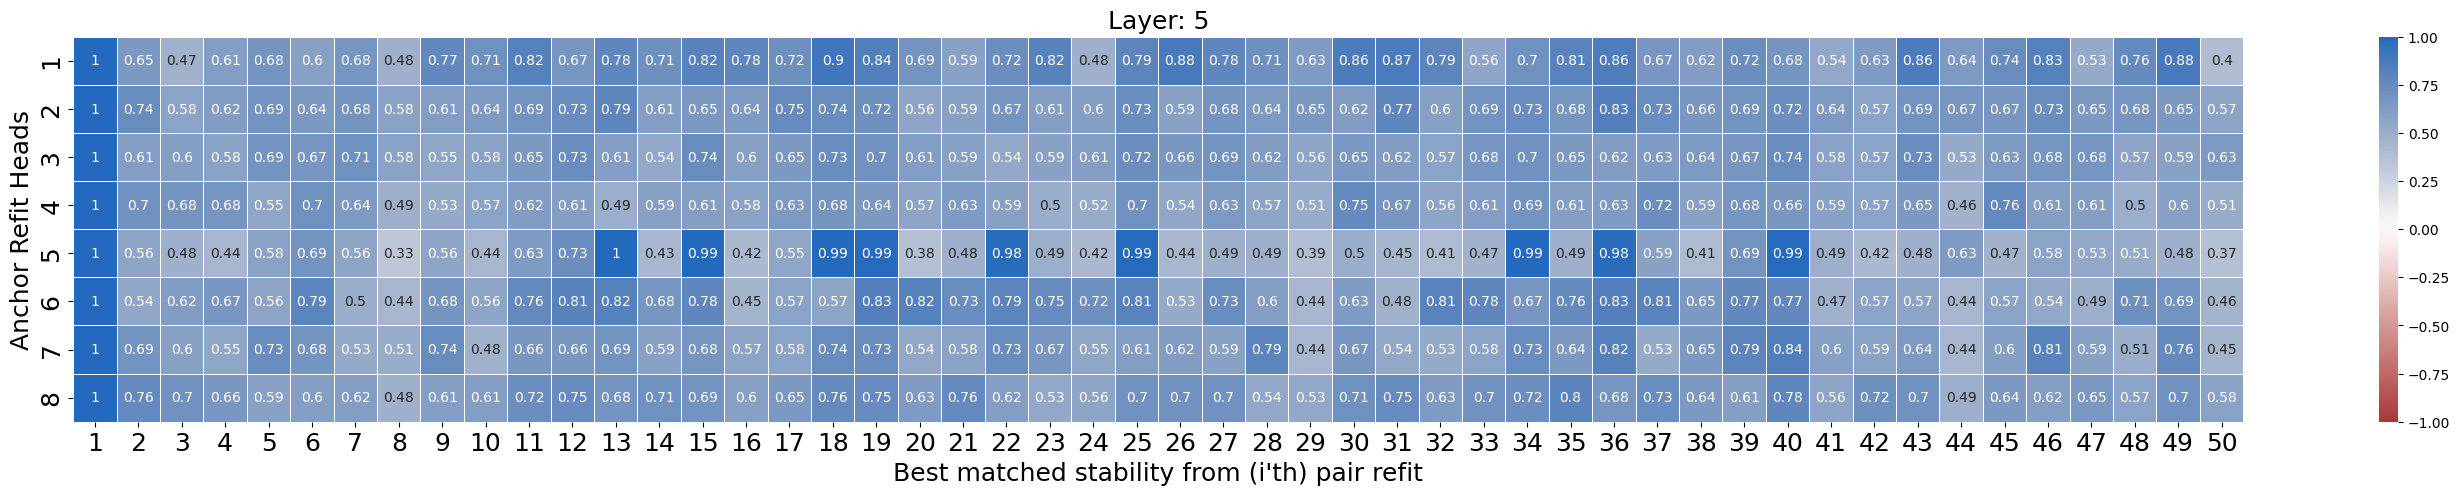

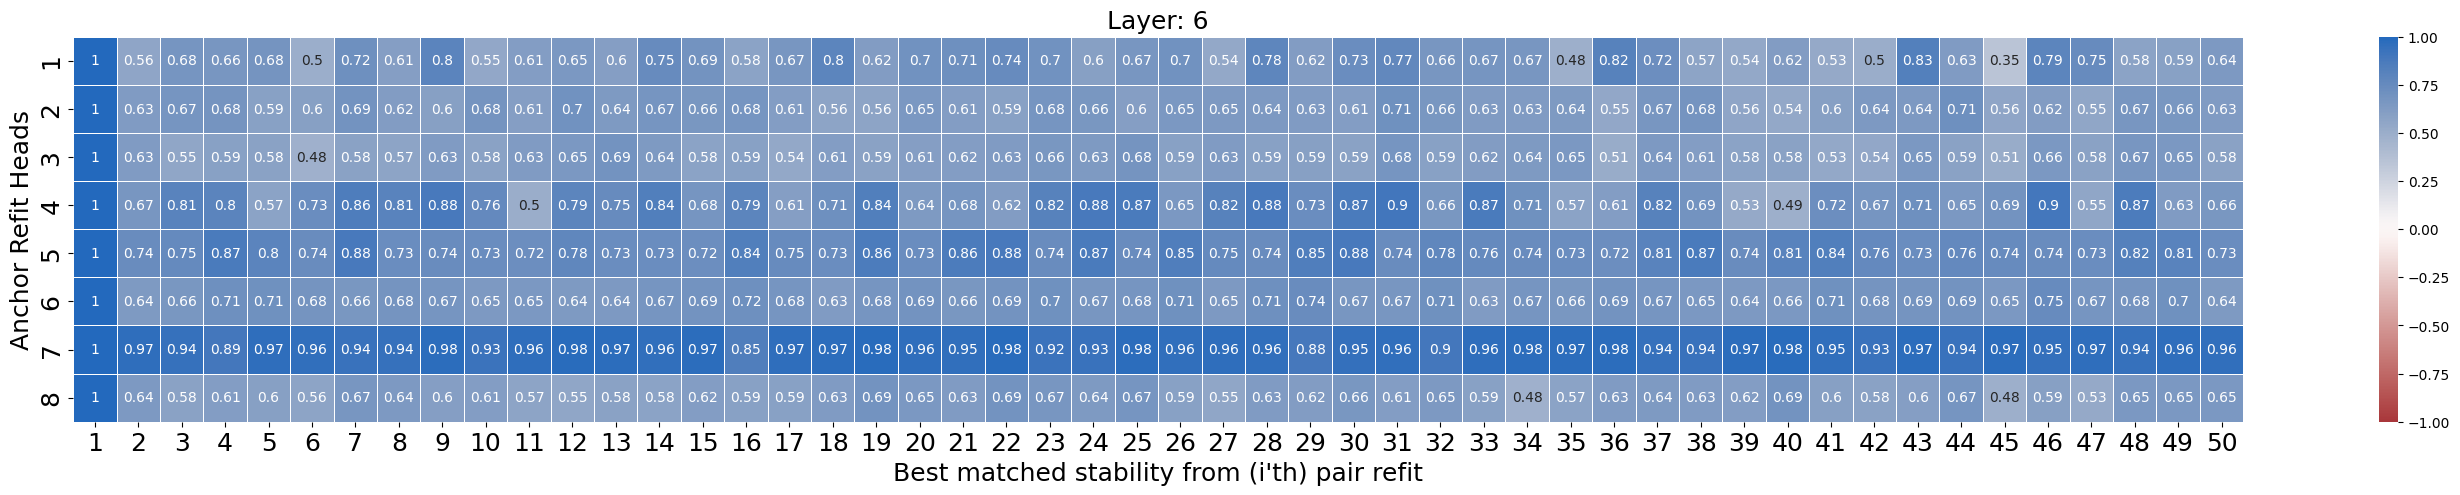

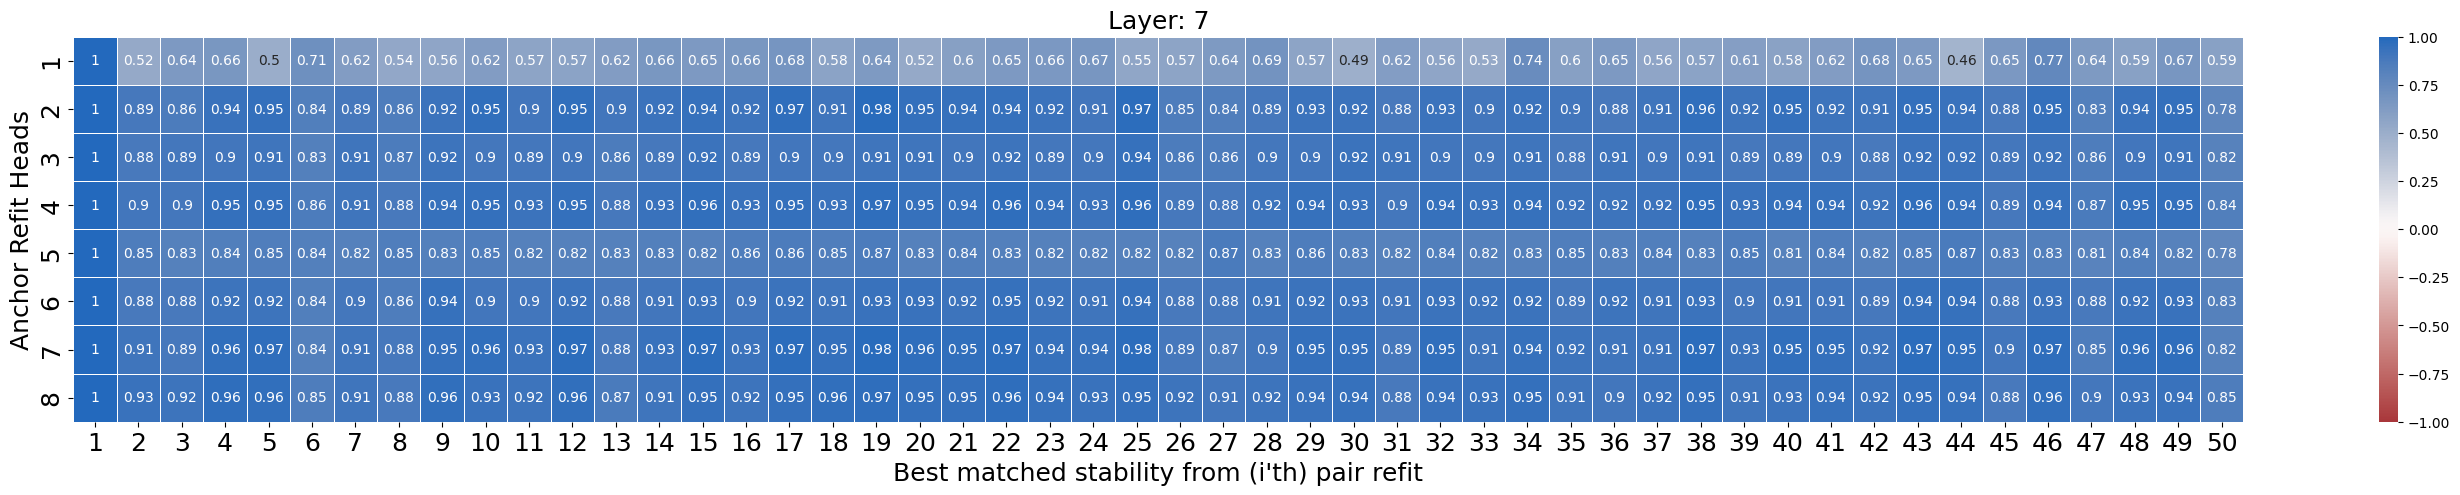

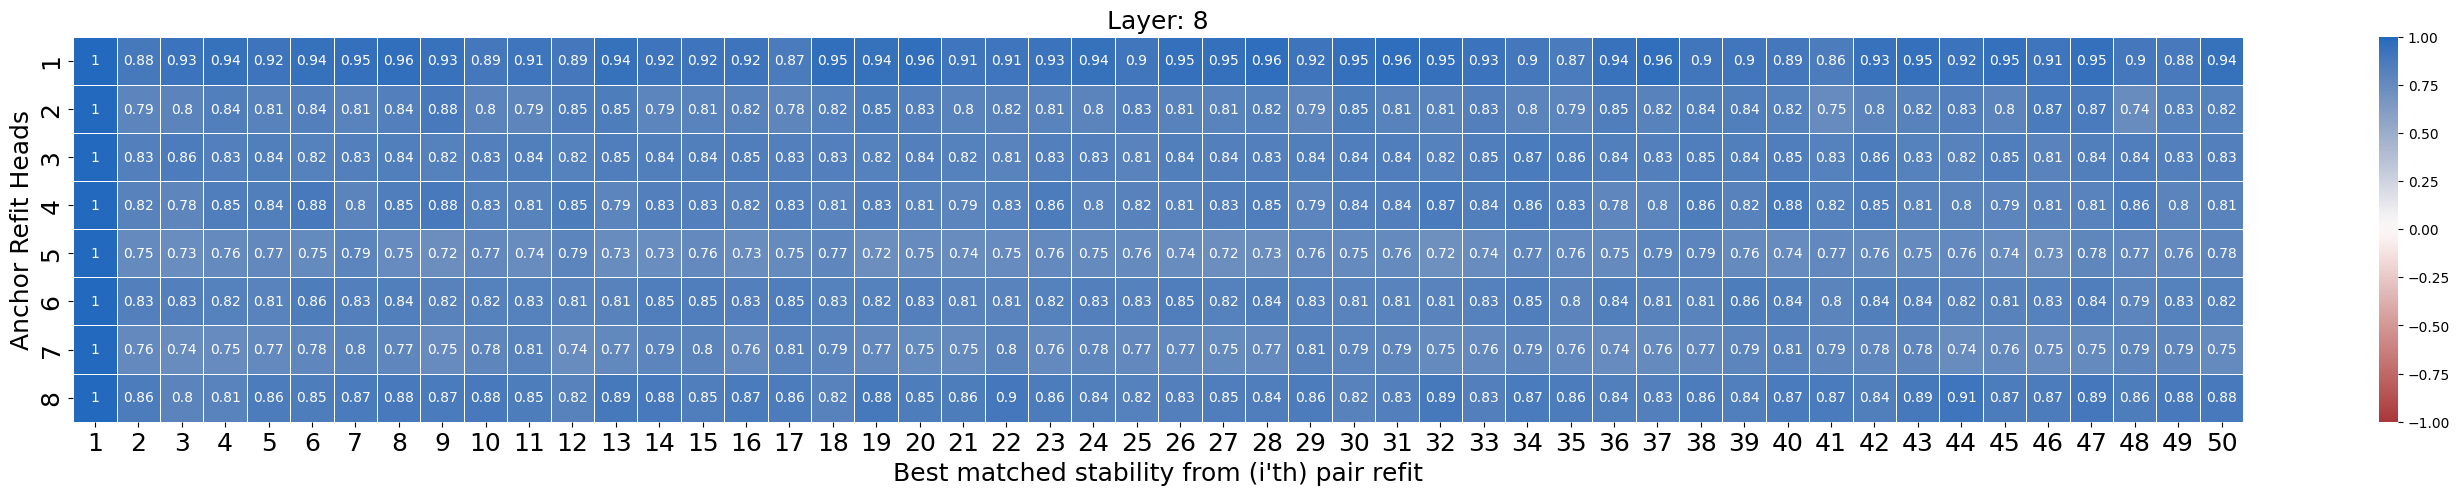

In [16]:
# Plot heatmaps for each layer
for layer_i in range(NUM_LAYERS):
    
    csh = prompts_cs_matrix[layer_i,:,:,:]
    csh = torch.mean(csh, -1)

    csh = csh.max(dim=-1, keepdim=True)
    csh = csh.values[:,:,0] 
    
    plt.subplots(figsize=(35,5))
    ax = sns.heatmap(csh, vmin=-1, vmax=1, linewidth=0.5, cmap='vlag_r', xticklabels=ticklabel_models, yticklabels=ticklabel_heads, annot=True)
    ax.set_xlabel('Best matched stability from (i\'th) pair refit', fontsize=18)
    ax.set_ylabel('Anchor Refit Heads', fontsize=18)
    ax.set_title(f"Layer: {layer_i+1}", fontsize=18)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    plt.show()


In [8]:
# Get best-matching head & Aggregate to get per-(layer, head_anchor)
results = []
for layer_i in range(NUM_LAYERS):
    csh = prompts_cs_matrix[layer_i,:,:,:]                # [head_anchor, model_i, head_pair, prompts]
    csh = torch.mean(csh, -1)                            # mean over prompts -> [head_anchor, model_i, head_pair]
    csh = csh.max(dim=-1, keepdim=True)                  # max over head_pair -> values shape [head_anchor, model_i, 1]
    csh = csh.values[:,:,0]                              # [head_anchor, model_i]
    csh = torch.cat([csh[:, :anchor], csh[:, anchor+1:]], dim=1) # remove comparison of anchor model with itself
    csh = csh.mean(dim=-1).reshape(NUM_HEADS, 1)         # mean over models -> [head_anchor, 1]

    # store results
    for head_anchor in range(NUM_HEADS):
        results.append({
            "layer": layer_i + 1,
            "head_anchor": head_anchor + 1,
            "cos_sim": csh[head_anchor].item()
        })

df_layer_sim = pd.DataFrame(results)

## Plot head-wise and layer-wise stability plot

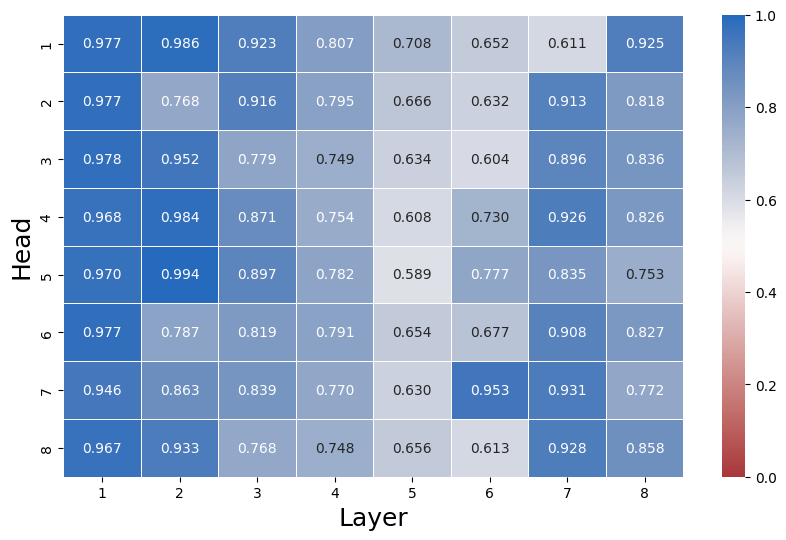

In [9]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Plot overall head-wise stability heatmap
heatmap_data = df_layer_sim.pivot(index="head_anchor", columns="layer", values="cos_sim")
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="vlag_r",
    vmin=0,
    vmax=1,
    xticklabels=ticklabel_layers,
    yticklabels=ticklabel_heads,
    linewidths=0.5
)
plt.xlabel("Layer", fontsize=18)
plt.ylabel("Head", fontsize=18)
#plt.title("Head-wise Stability")
plt.show()

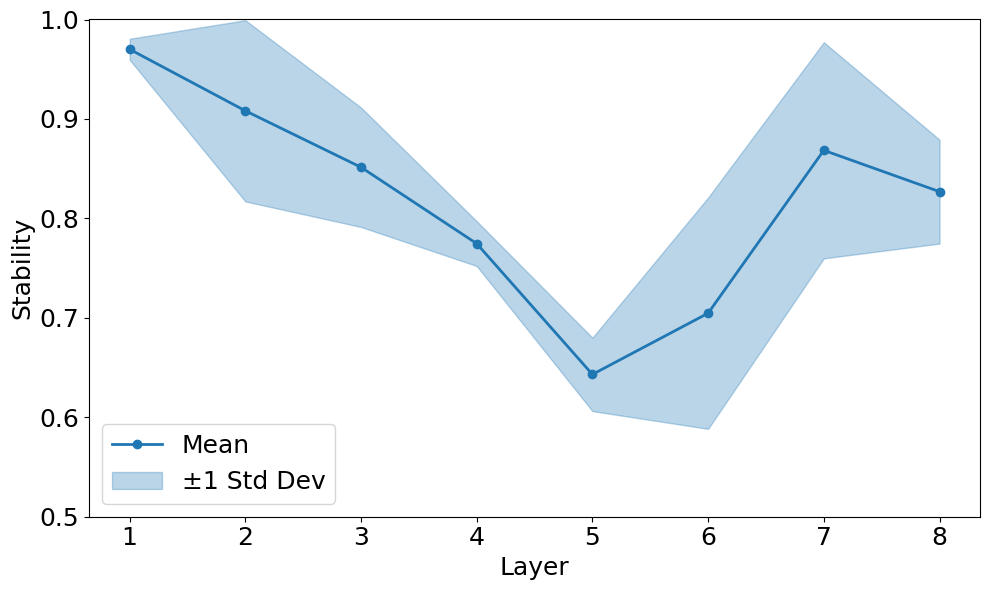

In [10]:
# Plot mean of head-wise stability (per layer) with std dev as shaded error band
layer_means = []
layer_stds = []
for layer in ticklabel_layers:
    layer_df = df_layer_sim[df_layer_sim['layer'] == layer]
    mean_cos_sim = layer_df['cos_sim'].mean()
    std_cos_sim = layer_df['cos_sim'].std()
    layer_means.append(mean_cos_sim)
    layer_stds.append(std_cos_sim)

plt.figure(figsize=(10, 6))

# Plot mean with shaded error band (±1 std dev)
plt.plot(ticklabel_layers, layer_means, marker='o', label='Mean', color='tab:blue', linewidth=2)
plt.fill_between(ticklabel_layers, 
                 np.array(layer_means) - np.array(layer_stds), 
                 np.array(layer_means) + np.array(layer_stds), 
                 alpha=0.3, color='tab:blue', label='±1 Std Dev')

plt.ylim(0.5, 1)
plt.xlabel('Layer', fontsize=18)
plt.ylabel('Stability', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
#plt.title('Layer-wise Stability with Standard Deviation')
plt.tight_layout()
plt.show()


## Layer-wise correlation between the stability and post-ablation change in perplexity

In [12]:
# -*- coding: utf-8 -*-
import math
import torch
import torch.nn.functional as F
from pathlib import Path
from typing import List, Tuple, Optional, Iterable, Dict
import pandas as pd
from tqdm import tqdm

# pip install transformer-lens if needed
from transformer_lens import HookedTransformer

# ----------------------------
# Config
# ----------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float32

BATCH_SIZE = 8              # tokens batch size (number of windows per forward)

# Provide your evaluation corpus here (list of strings) OR provide CORPUS_PATH
# TEXTS: List[str] = [
#     # Add a few sample lines if you want a quick sanity-check,
#     # then replace with your real corpus or use CORPUS_PATH below.
#     "The quick brown fox jumps over the lazy dog. " * 50,
# ]

TEXTS = prompts  # Use the previously defined prompts for evaluation
CORPUS_PATH: Optional[str] = None  # e.g., "data/valid.txt" (one doc per line). If set, overrides TEXTS.

# ----------------------------
# Utilities
# ----------------------------

def load_texts(corpus_path: Optional[str], texts: List[str]) -> List[str]:
    if corpus_path is not None:
        p = Path(corpus_path)
        assert p.exists(), f"Corpus path not found: {p}"
        with p.open("r", encoding="utf-8") as f:
            # Treat each line as a document; adjust if you prefer whole-file
            lines = [ln.strip() for ln in f if ln.strip()]
        return lines
    return texts

def tokenize_into_windows(
    model: HookedTransformer,
    docs: List[str],
    max_ctx: Optional[int] = None
) -> List[torch.Tensor]:
    """
    Tokenize each doc and cut into non-overlapping windows of length <= max_ctx.
    Returns a list of 1D LongTensors on the model device.
    """
    if max_ctx is None:
        max_ctx = model.cfg.n_ctx
    windows = []
    for doc in docs:
        # to_tokens handles BOS according to model.cfg.add_bos_token if prepend_bos=None
        toks = model.to_tokens(doc, prepend_bos=None, move_to_device=True).squeeze(0)  # [seq]
        L = toks.shape[0]
        if L <= 1:
            continue
        # stride = max_ctx - 1 ensures each window has predictive context for its next tokens
        stride = max_ctx - 1
        if stride < 2:
            stride = max_ctx  # fallback
        for start in range(0, L - 1, stride):
            window = toks[start : min(start + max_ctx, L)]
            if window.numel() > 1:
                windows.append(window)
    return windows

def batch_windows(
    windows: List[torch.Tensor],
    batch_size: int,
    pad_id: int
) -> Iterable[Tuple[torch.Tensor, torch.Tensor]]:
    """
    Yield (tokens_padded, mask_valid_next) per batch.
    tokens_padded: [B, T] Long
    mask_valid_next: [B, T-1] bool mask for loss positions (excludes padding next tokens)
    """
    for i in range(0, len(windows), batch_size):
        batch = windows[i:i+batch_size]
        max_len = max(w.shape[0] for w in batch)
        B = len(batch)
        tokens = torch.full((B, max_len), pad_id, dtype=torch.long, device=batch[0].device)
        next_valid_mask = torch.zeros((B, max_len-1), dtype=torch.bool, device=batch[0].device)
        for b, w in enumerate(batch):
            L = w.shape[0]
            tokens[b, :L] = w
            # positions 1..L-1 are valid prediction targets
            if L > 1:
                next_valid_mask[b, :L-1] = True
        yield tokens, next_valid_mask

@torch.no_grad()
def total_loss_over_windows(
    model: HookedTransformer,
    windows: List[torch.Tensor],
    batch_size: int,
    pad_id: int,
    hook: Optional[Tuple[str, callable]] = None
) -> Tuple[float, int]:
    """
    Returns (sum_loss, n_tokens_pred) over the dataset windows.
    If hook is provided, it should be (hook_name, hook_fn) for run_with_hooks.
    """
    sum_loss = 0.0
    n_tok_pred = 0

    for tokens, next_valid_mask in batch_windows(windows, batch_size, pad_id):
        if hook is None:
            logits = model(tokens)  # [B, T, d_vocab]
        else:
            logits = model.run_with_hooks(tokens, fwd_hooks=[hook])

        # shift for next-token prediction
        logits_next = logits[:, :-1, :]     # [B, T-1, V]
        targets = tokens[:, 1:]             # [B, T-1]

        # compute loss per position, mask out padding positions
        loss_pos = F.cross_entropy(
            logits_next.reshape(-1, logits_next.size(-1)),
            targets.reshape(-1),
            reduction="none",
        ).reshape(targets.shape)  # [B, T-1]

        loss_pos = loss_pos[next_valid_mask]
        sum_loss += loss_pos.sum().item()
        n_tok_pred += next_valid_mask.sum().item()

    return sum_loss, n_tok_pred

def ppl_from(sum_loss: float, n_tokens: int) -> float:
    if n_tokens == 0:
        return float("nan")
    return math.exp(sum_loss / n_tokens)

def make_head_ablate_hook(layer_idx: int, head_idx: int):
    """
    Zero a single head's z at blocks.{layer}.attn.hook_z.
    z shape: [B, T, n_heads, d_head]
    """
    def hook_fn(z, hook):
        # avoid in-place on shared tensors
        z = z.clone()
        z[:, :, head_idx, :] = 0.0
        return z
    hook_name = f"blocks.{layer_idx}.attn.hook_z"
    return hook_name, hook_fn

# ----------------------------
# Main
# ----------------------------

def main(inst_i = 0):

    model = models[inst_i]
    model.eval()
    torch.set_grad_enabled(False)

    docs = load_texts(CORPUS_PATH, TEXTS)
    assert len(docs) > 0, "No documents provided. Set TEXTS or CORPUS_PATH."

    print("Tokenizing and windowing...")
    windows = tokenize_into_windows(model, docs, max_ctx=model.cfg.n_ctx)
    assert len(windows) > 0, "No usable token windows (documents too short?)."

    # pick a safe pad id (GPT-2 has no pad token; eos is fine since we'll mask)
    pad_id = getattr(model.tokenizer, "pad_token_id", None)
    if pad_id is None or pad_id == -1:
        pad_id = model.tokenizer.eos_token_id

    print("Computing baseline perplexity...")
    base_loss_sum, base_tok = total_loss_over_windows(
        model, windows, BATCH_SIZE, pad_id, hook=None
    )
    base_ppl = ppl_from(base_loss_sum, base_tok)
    print(f"Baseline PPL: {base_ppl:.4f} over {base_tok} tokens")

    n_layers = model.cfg.n_layers
    n_heads = model.cfg.n_heads

    records = []
    pbar = tqdm(total=n_layers * n_heads, desc="Head ablations")
    for layer in range(n_layers):
        for head in range(n_heads):
            hook = make_head_ablate_hook(layer, head)
            loss_sum, tok = total_loss_over_windows(
                model, windows, BATCH_SIZE, pad_id, hook=hook
            )
            ppl = ppl_from(loss_sum, tok)
            delta = ppl - base_ppl
            rel = (delta / base_ppl) if base_ppl > 0 else float("nan")

            records.append({
                "layer": layer+1,
                "head": head+1,
                "ppl_ablated": ppl,
                "delta_ppl": delta,
                "rel_delta_ppl": rel,
                "tokens": tok,
            })
            pbar.update(1)
    pbar.close()

    df = pd.DataFrame.from_records(records).sort_values(
        ["delta_ppl", "layer", "head"], ascending=[False, True, True]
    )
    print("\nTop 10 heads by ΔPPL (most important by this metric):")
    print(df.head(10).to_string(index=False, float_format=lambda x: f"{x:,.6f}"))


    # Also print baseline at the end for convenience
    print(f"\nBaseline PPL: {base_ppl:.6f}")
    return df

inst_i = 0  # Change this to select which model instance to evaluate
df = main(inst_i=inst_i)


Tokenizing and windowing...
Computing baseline perplexity...
Baseline PPL: 103.0025 over 5175 tokens


Head ablations: 100%|██████████| 64/64 [00:36<00:00,  1.74it/s]


Top 10 heads by ΔPPL (most important by this metric):
 layer  head  ppl_ablated  delta_ppl  rel_delta_ppl  tokens
     2     5   308.104098 205.101627       1.991230    5175
     5     5   113.647085  10.644613       0.103343    5175
     2     8   113.429674  10.427203       0.101233    5175
     1     1   110.749162   7.746691       0.075209    5175
     5     1   109.422338   6.419867       0.062327    5175
     6     8   108.570420   5.567949       0.054056    5175
     7     1   107.970268   4.967797       0.048230    5175
     6     1   107.630041   4.627570       0.044927    5175
     6     5   107.517113   4.514641       0.043830    5175
     4     1   107.342219   4.339748       0.042132    5175

Baseline PPL: 103.002471


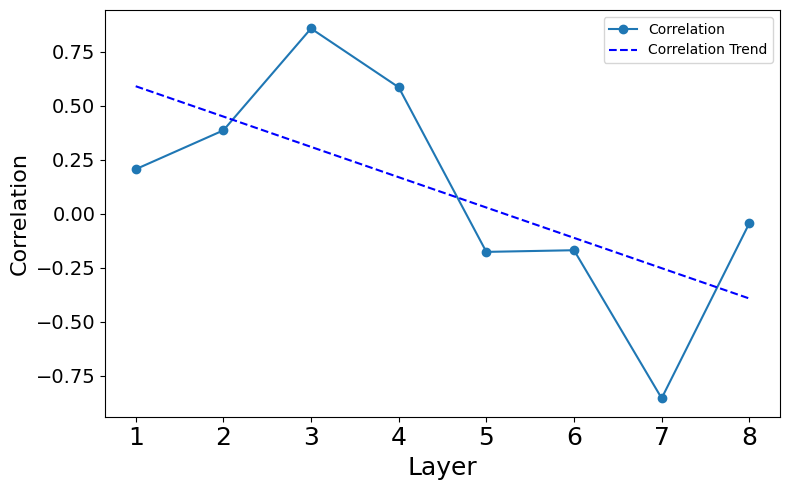

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# Plotting layer-wise correlation between 'stability' and 'ablation perplexity'
layer_corrs_pearson = []
layer_corrs_kendall = []
layers = sorted(df['layer'].unique())
for i, layer in enumerate(layers):
    heads = sorted(df[df['layer'] == layer]['head'].values)

    delta_ppl = df[(df['layer'] == layer) & (df['head'].isin(heads))].sort_values('head')['delta_ppl'].values
    cos_sim = df_layer_sim[df_layer_sim['layer'] == layer].sort_values('head_anchor')['cos_sim'].values

    if len(cos_sim) == len(delta_ppl):
        corr_pearson = np.corrcoef(delta_ppl, cos_sim)[0, 1]
        corr_kendall, _ = kendalltau(delta_ppl, cos_sim)
    else:
        corr_pearson = np.nan
        corr_kendall = np.nan
    layer_corrs_pearson.append(corr_pearson)
    layer_corrs_kendall.append(corr_kendall)

plt.figure(figsize=(8, 5))
plt.plot(layers, layer_corrs_pearson, marker='o', label='Correlation')
#plt.plot(layers, layer_corrs_kendall, marker='s', label='Kendall')

# Add trend lines
if len(layers) > 1:
    pearson_fit = np.polyfit(layers, layer_corrs_pearson, 1)
    pearson_trend = np.polyval(pearson_fit, layers)
    plt.plot(layers, pearson_trend, 'b--', label='Correlation Trend')

    kendall_fit = np.polyfit(layers, layer_corrs_kendall, 1)
    kendall_trend = np.polyval(kendall_fit, layers)
    #plt.plot(layers, kendall_trend, 'g--', label='Kendall Trend')

plt.xlabel('Layer', fontsize=18)
plt.ylabel('Correlation', fontsize=16)
#plt.title('Layer-wise correlation between the "stability" value and the “ablation perplexity delta” of all the heads')
plt.xticks(fontsize=18)
plt.yticks(fontsize=14)
plt.legend(fontsize=14) 
plt.xticks(layers)
plt.legend()
plt.tight_layout()
plt.show()


## Correlation between Query-weight norm and layer-wise stability

In [19]:
import os

inst_i = 0  # Index of the model instance to analyze
attn_only = models[inst_i].cfg.attn_only
wd = True if "_wd" in arch else False

#SCRATCH = os.getenv("SCRATCH")
corr_df_path = SCRATCH + "/df/comm/df_corr_csh.pkl"

# Check if the DataFrame exists, otherwise create a new one
if os.path.exists(corr_df_path):
    corr_df = pd.read_pickle(corr_df_path)
else:
    corr_df = pd.DataFrame()


q_norms = []
k_norms = []
v_norms = []
o_norms = []
w_in_norms = []
w_out_norms = []

for layer in range(NUM_LAYERS):

    q = models[inst_i].blocks[layer].attn.W_Q.detach().cpu().numpy()
    k = models[inst_i].blocks[layer].attn.W_K.detach().cpu().numpy()
    o = models[inst_i].blocks[layer].attn.W_O.detach().cpu().numpy()
    
    v = models[inst_i].blocks[layer].attn.W_V.detach().cpu().numpy()
    q_norms.append(np.linalg.norm(q))
    k_norms.append(np.linalg.norm(k))
    v_norms.append(np.linalg.norm(v))
    o_norms.append(np.linalg.norm(o))

    if not attn_only:
        # Calculate L2 norm for MLP weights (W_in and W_out)
        w_in = models[inst_i].blocks[layer].mlp.W_in.detach().cpu().numpy()
        w_out = models[inst_i].blocks[layer].mlp.W_out.detach().cpu().numpy()
        
        w_in_norms.append(np.linalg.norm(w_in))
        w_out_norms.append(np.linalg.norm(w_out))

csh_layer_mean = np.array([])
for layer_i in range(NUM_LAYERS):
    csh_mean = df_layer_sim[df_layer_sim['layer'] == layer_i + 1]['cos_sim'].mean()
    csh_layer_mean = np.append(csh_layer_mean, csh_mean)

# Convert all norm lists to numpy arrays
q_norms_np = np.array(q_norms)
v_norms_np = np.array(v_norms)
k_norms_np = np.array(k_norms)
o_norms_np = np.array(o_norms)
if not attn_only:
    w_out_norms_np = np.array(w_out_norms)
    w_in_norms_np = np.array(w_in_norms)


# Compute correlations
corr_q = np.corrcoef(csh_layer_mean, q_norms_np)[0, 1]
corr_v = np.corrcoef(csh_layer_mean, v_norms_np)[0, 1]
corr_k = np.corrcoef(csh_layer_mean, k_norms_np)[0, 1]
corr_o = np.corrcoef(csh_layer_mean, o_norms_np)[0, 1]
if not attn_only:
    corr_w_out = np.corrcoef(csh_layer_mean, w_out_norms_np)[0, 1]
    corr_w_in = np.corrcoef(csh_layer_mean, w_in_norms_np)[0, 1]

print("Correlation between csh_layer_mean and q_norms:", corr_q)
print("Correlation between csh_layer_mean and v_norms:", corr_v)
print("Correlation between csh_layer_mean and k_norms:", corr_k)
print("Correlation between csh_layer_mean and o_norms:", corr_o)
if not attn_only:
    print("Correlation between csh_layer_mean and w_out_norms:", corr_w_out)
    print("Correlation between csh_layer_mean and w_in_norms:", corr_w_in)

# Add new row with correlations and model config
new_row = {
    'corr_q': corr_q,
    'corr_v': corr_v,
    'corr_k': corr_k,
    'corr_o': corr_o,
    'corr_w_out': corr_w_out if not attn_only else None,
    'corr_w_in': corr_w_in if not attn_only else None,
    'n_layers': NUM_LAYERS,
    'n_heads': NUM_HEADS,
    'attn_only': attn_only,
    "wd": wd,
    'instance': 0
}
corr_df = pd.concat([corr_df, pd.DataFrame([new_row])], ignore_index=True)
corr_df.to_pickle(corr_df_path)


Correlation between csh_layer_mean and q_norms: -0.031545835341075135
Correlation between csh_layer_mean and v_norms: -0.029995674528144396
Correlation between csh_layer_mean and k_norms: 0.01625539418790218
Correlation between csh_layer_mean and o_norms: -0.20744932013706285


/tmp/ipykernel_3910188/229533596.py:90: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_df = pd.concat([corr_df, pd.DataFrame([new_row])], ignore_index=True)


In [9]:
corr_df

,corr_q,corr_v,corr_k,corr_o,corr_w_out,corr_w_in,n_layers,n_heads,attn_only,wd,instance
0,-0.844714,-0.363475,-0.886929,-0.334962,-0.427699,-0.031233,8,8,False,False,0
1,-0.940659,-0.606883,-0.976857,-0.516340,-0.452674,0.980942,4,8,False,False,0
2,-0.216176,-0.824720,-0.349547,-0.960672,-0.894158,0.496589,8,16,False,False,0
3,-0.674956,-0.548318,0.747536,-0.624046,0.096812,-0.189912,8,16,False,True,0
4,-0.221279,-0.041926,-0.249312,-0.491677,NaN,NaN,4,8,True,True,0
5,-0.031546,-0.029996,0.016255,-0.207449,NaN,NaN,8,8,True,True,0
6,-0.694139,-0.148050,-0.783664,-0.002399,NaN,NaN,8,16,True,False,0
7,-0.637492,-0.541734,0.748695,-0.459520,NaN,NaN,8,16,True,True,0
8,-0.955499,-0.502353,0.779948,-0.198834,NaN,NaN,4,16,True,True,0
9,-0.649438,-0.568532,-0.769157,-0.418615,NaN,NaN,4,16,True,False,0


In [ ]:
# import os

# inst_i = 0  # Index of the model instance to analyze
# attn_only = models[inst_i].cfg.attn_only

# #SCRATCH = os.getenv("SCRATCH")
# corr_df_path = SCRATCH + "/df/comm/df_corr_csh.pkl"

# # Check if the DataFrame exists, otherwise create a new one
# if os.path.exists(corr_df_path):
#     corr_df = pd.read_pickle(corr_df_path)
# else:
#     corr_df = pd.DataFrame()


# q_norms = []
# k_norms = []
# v_norms = []
# o_norms = []
# w_in_norms = []
# w_out_norms = []

# for layer in range(NUM_LAYERS):

#     q = models[inst_i].blocks[layer].attn.W_Q.detach().cpu().numpy()
#     k = models[inst_i].blocks[layer].attn.W_K.detach().cpu().numpy()
#     o = models[inst_i].blocks[layer].attn.W_O.detach().cpu().numpy()
#     # Calculate L2 norm for MLP weights (W_in and W_out)
#     w_in = models[inst_i].blocks[layer].mlp.W_in.detach().cpu().numpy()
#     w_out = models[inst_i].blocks[layer].mlp.W_out.detach().cpu().numpy()
        
#     w_in_norms.append(np.linalg.norm(w_in))
#     w_out_norms.append(np.linalg.norm(w_out))
#     v = models[inst_i].blocks[layer].attn.W_V.detach().cpu().numpy()
#     q_norms.append(np.linalg.norm(q))
#     k_norms.append(np.linalg.norm(k))
#     v_norms.append(np.linalg.norm(v))
#     o_norms.append(np.linalg.norm(o))

# csh_layer_mean = np.array([])
# for layer_i in range(NUM_LAYERS):
#     # [ layer, head_anchor, model_i, head_pair, ind]
#     csh = prompts_cs_matrix[layer_i, :, :, :]
#     csh = torch.mean(csh, -1)
#     csh = csh.max(dim=-1, keepdim=True)
#     csh = csh.values[:, :, 0]
#     csh_mean = torch.mean(csh, dim=1)  # shape: (NUM_HEADS, NUM_MODELS)
#     csh_mean = torch.mean(csh_mean, dim=0)  # shape: (NUM_MODELS,)
#     csh_layer_mean = np.append(csh_layer_mean, csh_mean.detach().cpu().numpy())

# # Convert all norm lists to numpy arrays
# q_norms_np = np.array(q_norms)
# v_norms_np = np.array(v_norms)
# k_norms_np = np.array(k_norms)
# o_norms_np = np.array(o_norms)
# w_out_norms_np = np.array(w_out_norms)
# w_in_norms_np = np.array(w_in_norms)


# # Compute correlations
# corr_q = np.corrcoef(csh_layer_mean, q_norms_np)[0, 1]
# corr_v = np.corrcoef(csh_layer_mean, v_norms_np)[0, 1]
# corr_k = np.corrcoef(csh_layer_mean, k_norms_np)[0, 1]
# corr_o = np.corrcoef(csh_layer_mean, o_norms_np)[0, 1]
# corr_w_out = np.corrcoef(csh_layer_mean, w_out_norms_np)[0, 1]
# corr_w_in = np.corrcoef(csh_layer_mean, w_in_norms_np)[0, 1]

# print("Correlation between csh_layer_mean and q_norms:", corr_q)
# print("Correlation between csh_layer_mean and v_norms:", corr_v)
# print("Correlation between csh_layer_mean and k_norms:", corr_k)
# print("Correlation between csh_layer_mean and o_norms:", corr_o)
# print("Correlation between csh_layer_mean and w_out_norms:", corr_w_out)
# print("Correlation between csh_layer_mean and w_in_norms:", corr_w_in)

# # Add new row with correlations and model config
# new_row = {
#     'corr_q': corr_q,
#     'corr_v': corr_v,
#     'corr_k': corr_k,
#     'corr_o': corr_o,
#     'corr_w_out': corr_w_out,
#     'corr_w_in': corr_w_in,
#     'n_layers': NUM_LAYERS,
#     'n_heads': NUM_HEADS,
#     'attn_only': attn_only,
#     'instance': 0
# }
# corr_df = pd.concat([corr_df, pd.DataFrame([new_row])], ignore_index=True)
# #corr_df.to_pickle(corr_df_path)


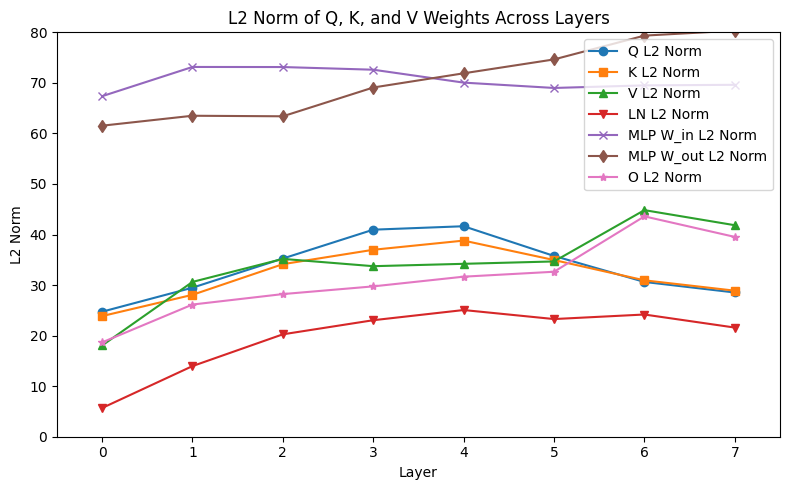

In [35]:
q_norms = []
k_norms = []
v_norms = []
o_norms = []
w_in_norms = []
w_out_norms = []
ln_norms = []
# inst_i = 0  # Index of the model instance to analyze

for layer in range(NUM_LAYERS):
    q = models[inst_i].blocks[layer].attn.W_Q.detach().cpu().numpy()
    k = models[inst_i].blocks[layer].attn.W_K.detach().cpu().numpy()
    o = models[inst_i].blocks[layer].attn.W_O.detach().cpu().numpy()
    ln = models[inst_i].blocks[layer].ln1.w.detach().cpu().numpy()
    # Calculate L2 norm for MLP weights (W_in and W_out)
    w_in = models[inst_i].blocks[layer].mlp.W_in.detach().cpu().numpy()
    w_out = models[inst_i].blocks[layer].mlp.W_out.detach().cpu().numpy()

    w_in_norms.append(np.linalg.norm(w_in))
    w_out_norms.append(np.linalg.norm(w_out))
    v = models[inst_i].blocks[layer].attn.W_V.detach().cpu().numpy()
    q_norms.append(np.linalg.norm(q))
    k_norms.append(np.linalg.norm(k))
    v_norms.append(np.linalg.norm(v))
    o_norms.append(np.linalg.norm(o))
    ln_norms.append(np.linalg.norm(ln))

plt.figure(figsize=(8, 5))
plt.plot(range(NUM_LAYERS), q_norms, marker='o', label='Q L2 Norm')
plt.plot(range(NUM_LAYERS), k_norms, marker='s', label='K L2 Norm')
plt.plot(range(NUM_LAYERS), v_norms, marker='^', label='V L2 Norm')
plt.plot(range(NUM_LAYERS), ln_norms, marker='v', label='LN L2 Norm') # Adjust the y-axis limit as needed
plt.plot(range(NUM_LAYERS), w_in_norms, marker='x', label='MLP W_in L2 Norm')
plt.plot(range(NUM_LAYERS), w_out_norms, marker='d', label='MLP W_out L2 Norm') # Adjust the y-axis limit as needed
plt.plot(range(NUM_LAYERS), o_norms, marker='*', label='O L2 Norm') # Adjust the y-axis limit as needed
plt.xlim(-0.5, NUM_LAYERS - 0.5)
plt.xlabel('Layer')
plt.ylabel('L2 Norm')
plt.title('L2 Norm of Q, K, and V Weights Across Layers')
plt.xticks(range(NUM_LAYERS))
plt.legend()
plt.ylim(0,80)
plt.tight_layout()
plt.show()